# This `ipynb` file serves the purpose to check our experimentations' results.

---
---

## 1. Create a combined CSV of the outputs

In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Find CSV in output/ and sub-folders
csv_files = list(Path('../output').rglob('*.csv'))

# Combine CSV
df = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)

# Sort CSV by ['dataset', 'classifier']
df = df.sort_values(['dataset', 'classifier'], ascending=True).reset_index(drop=True)

df['total_time'] = df['train_time'] + df['test_time'] + df['generate_kernel_time'] + df['apply_kernel_on_train_time'] + df['apply_kernel_on_test_time']

# Display
display(df.head(30))

,timestamp,itr,classifier,num_features,dataset,train_acc,train_time,test_acc,test_time,generate_kernel_time,apply_kernel_on_train_time,apply_kernel_on_test_time,train_transform_time,test_transform_time,physical_cores,logical_cores,max_freq,min_freq,memory,total_time
0,2026-04-12 17:58:10,0,MultiRocket_10000,10000,Crop,-1,3.981797,0.748631,0.376854,0.003194,0.230747,0.490592,0.000398,0.000725,10,10,4,0,17.0,5.083183
1,2026-04-12 17:59:04,0,MultiRocket_49728,49728,Crop,-1,17.007639,0.753988,4.091698,0.009472,0.911977,2.049311,0.000408,0.001154,10,10,4,0,17.0,24.070097
2,2026-04-12 18:03:11,0,ker7_MultiRocket_20720,20720,Crop,-1,12.621512,0.751726,0.751807,0.004408,0.369528,0.828867,0.000366,0.000703,10,10,4,0,17.0,14.576122
3,2026-04-12 18:01:40,0,mlp_MultiRocket_49728,49728,Crop,-1,36.735356,0.728810,1.798680,0.009519,0.881211,1.953335,0.000312,0.000667,10,10,4,0,17.0,41.378101
4,2026-04-12 18:02:37,0,rf_MultiRocket_49728,49728,Crop,-1,16.694688,0.759940,1.918042,0.009182,0.888521,2.036433,0.000327,0.000682,10,10,4,0,17.0,21.546866
5,2026-04-12 18:00:30,0,skew_MultiRocket_62160,62160,Crop,-1,11.791475,0.748036,5.370255,0.009826,1.006383,2.233100,0.000313,0.000727,10,10,4,0,17.0,20.411038
6,2026-04-12 17:59:51,0,var_MultiRocket_62160,62160,Crop,-1,15.102093,0.755357,6.329398,0.009382,0.942033,2.079066,0.000383,0.000733,10,10,4,0,17.0,24.461972
7,2026-04-12 17:51:00,0,MultiRocket_10000,10000,ElectricDevices,-1,9.197103,0.728699,0.168387,0.006050,0.476870,0.392664,0.000671,0.000719,10,10,4,0,17.0,10.241073
8,2026-04-12 17:51:41,0,MultiRocket_49728,49728,ElectricDevices,-1,21.356969,0.710543,0.829270,0.014629,1.874052,1.608996,0.000889,0.001484,10,10,4,0,17.0,25.683916
9,2026-04-12 17:57:33,0,ker7_MultiRocket_20720,20720,ElectricDevices,-1,15.262001,0.717417,0.357970,0.006803,0.772875,0.664123,0.000883,0.000723,10,10,4,0,17.0,17.063772


---
---

## 2. Our experiments' dataset infos

In [2]:
name = ["InsectWingbeatSound", "StarLightCurves", "ElectricDevices", "Crop"]
train = [220, 1000, 8926, 7200]
test = [1980, 8236, 7711, 16800]
total = [2200, 9236, 16637, 24000]

df_num = pd.DataFrame({'Name': name, 'Train': train, 'Test': test, 'Total': total})
display(df_num)

,Name,Train,Test,Total
0,InsectWingbeatSound,220,1980,2200
1,StarLightCurves,1000,8236,9236
2,ElectricDevices,8926,7711,16637
3,Crop,7200,16800,24000


---
---


# 3-1. Our first approach

We tried two times by adding a **5th pooling operator** : the variance and the skewness.  
Having now 62 160 features (84 * 74 * 2 * 5).

Here are the charts for `test_acc` and `total_time`.

,timestamp,itr,classifier,num_features,dataset,train_acc,train_time,test_acc,test_time,generate_kernel_time,apply_kernel_on_train_time,apply_kernel_on_test_time,train_transform_time,test_transform_time,physical_cores,logical_cores,max_freq,min_freq,memory,total_time
0,2026-04-12 17:58:10,0,MultiRocket_10000,10000,Crop,-1,3.981797,0.748631,0.376854,0.003194,0.230747,0.490592,0.000398,0.000725,10,10,4,0,17.0,5.083183
1,2026-04-12 17:59:04,0,MultiRocket_49728,49728,Crop,-1,17.007639,0.753988,4.091698,0.009472,0.911977,2.049311,0.000408,0.001154,10,10,4,0,17.0,24.070097
5,2026-04-12 18:00:30,0,skew_MultiRocket_62160,62160,Crop,-1,11.791475,0.748036,5.370255,0.009826,1.006383,2.233100,0.000313,0.000727,10,10,4,0,17.0,20.411038
6,2026-04-12 17:59:51,0,var_MultiRocket_62160,62160,Crop,-1,15.102093,0.755357,6.329398,0.009382,0.942033,2.079066,0.000383,0.000733,10,10,4,0,17.0,24.461972
7,2026-04-12 17:51:00,0,MultiRocket_10000,10000,ElectricDevices,-1,9.197103,0.728699,0.168387,0.006050,0.476870,0.392664,0.000671,0.000719,10,10,4,0,17.0,10.241073
8,2026-04-12 17:51:41,0,MultiRocket_49728,49728,ElectricDevices,-1,21.356969,0.710543,0.829270,0.014629,1.874052,1.608996,0.000889,0.001484,10,10,4,0,17.0,25.683916
12,2026-04-12 17:53:42,0,skew_MultiRocket_62160,62160,ElectricDevices,-1,29.243297,0.722993,1.035460,0.014973,2.019172,1.756755,0.000925,0.001121,10,10,4,0,17.0,34.069656
13,2026-04-12 17:52:42,0,var_MultiRocket_62160,62160,ElectricDevices,-1,26.466493,0.735184,1.045705,0.014984,1.987412,1.749120,0.000970,0.001347,10,10,4,0,17.0,31.263715
14,2026-03-31 15:38:33,0,MultiRocket_10000,10000,InsectWingbeatSound,-1,0.694419,0.642424,0.042348,0.010279,0.027257,0.187848,0.000049,0.000408,10,10,4,0,17.0,0.962151
15,2026-03-31 15:38:45,0,MultiRocket_49728,49728,InsectWingbeatSound,-1,1.628165,0.637374,0.225057,0.027484,0.097459,0.855516,0.000080,0.000465,10,10,4,0,17.0,2.833681



===== Dataset: Crop =====



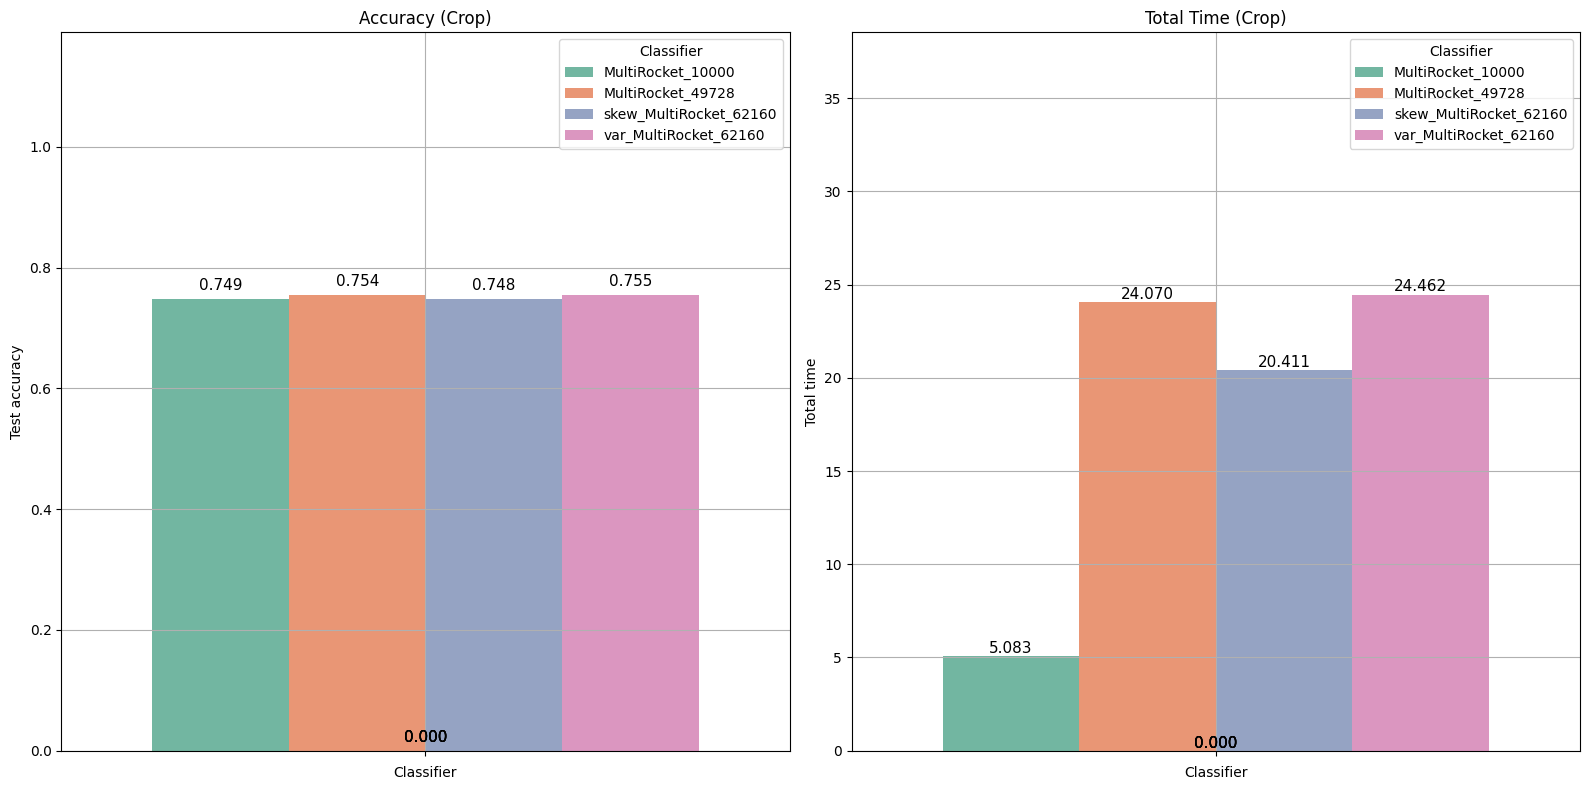


===== Dataset: ElectricDevices =====



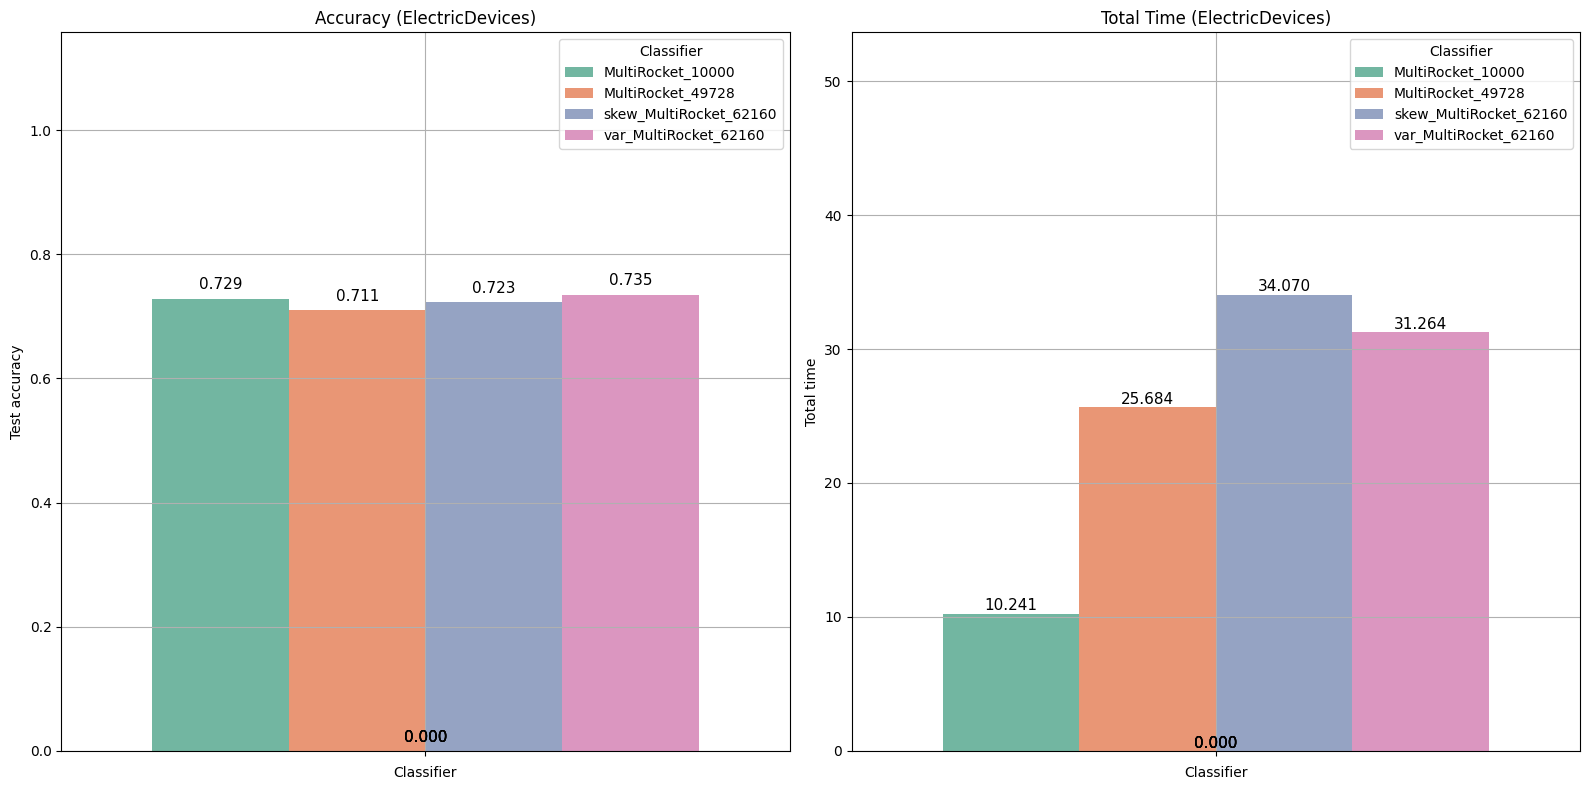


===== Dataset: InsectWingbeatSound =====



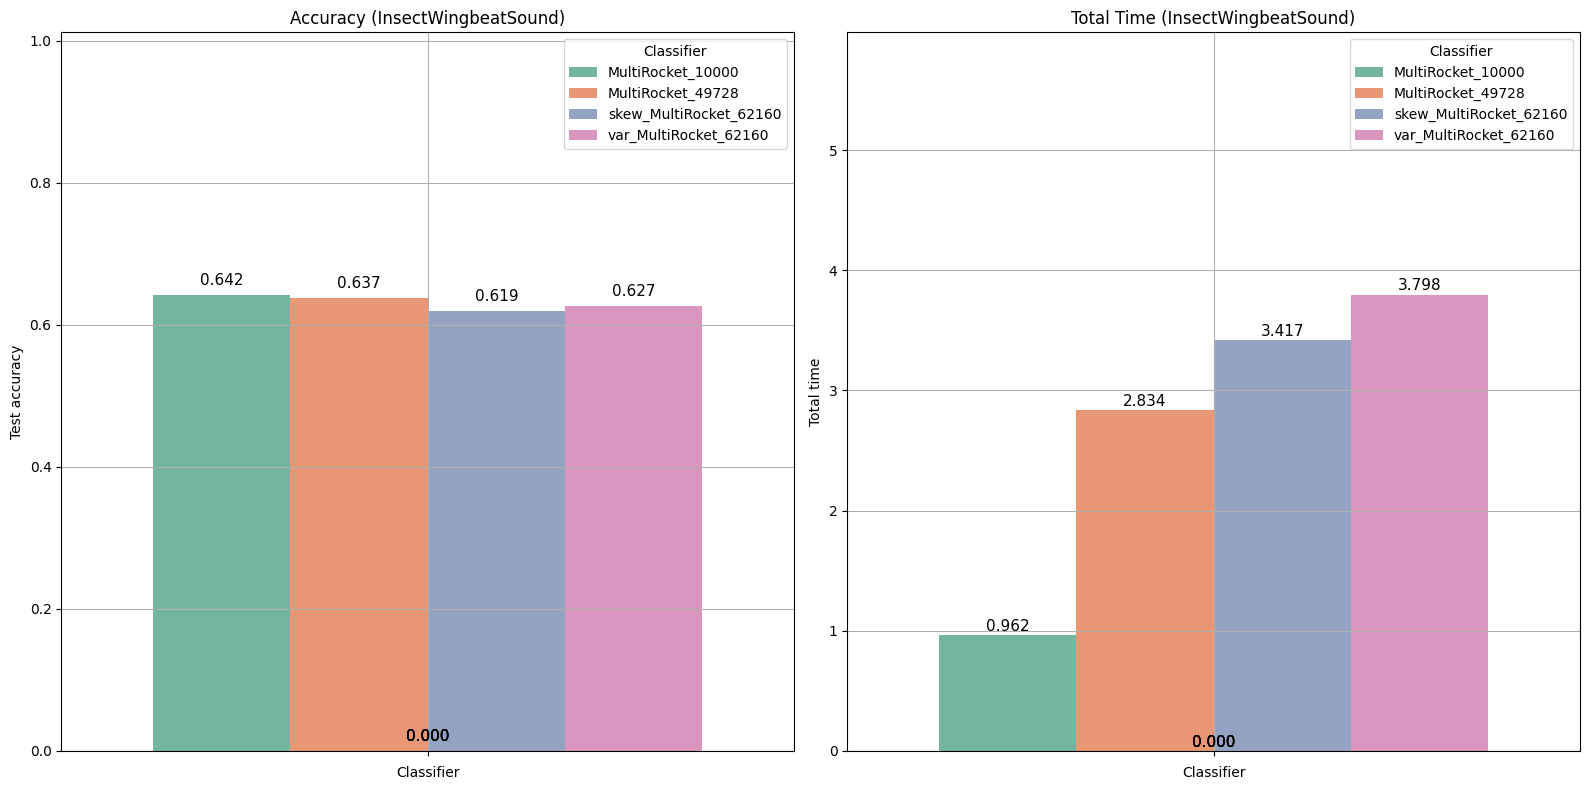


===== Dataset: StarLightCurves =====



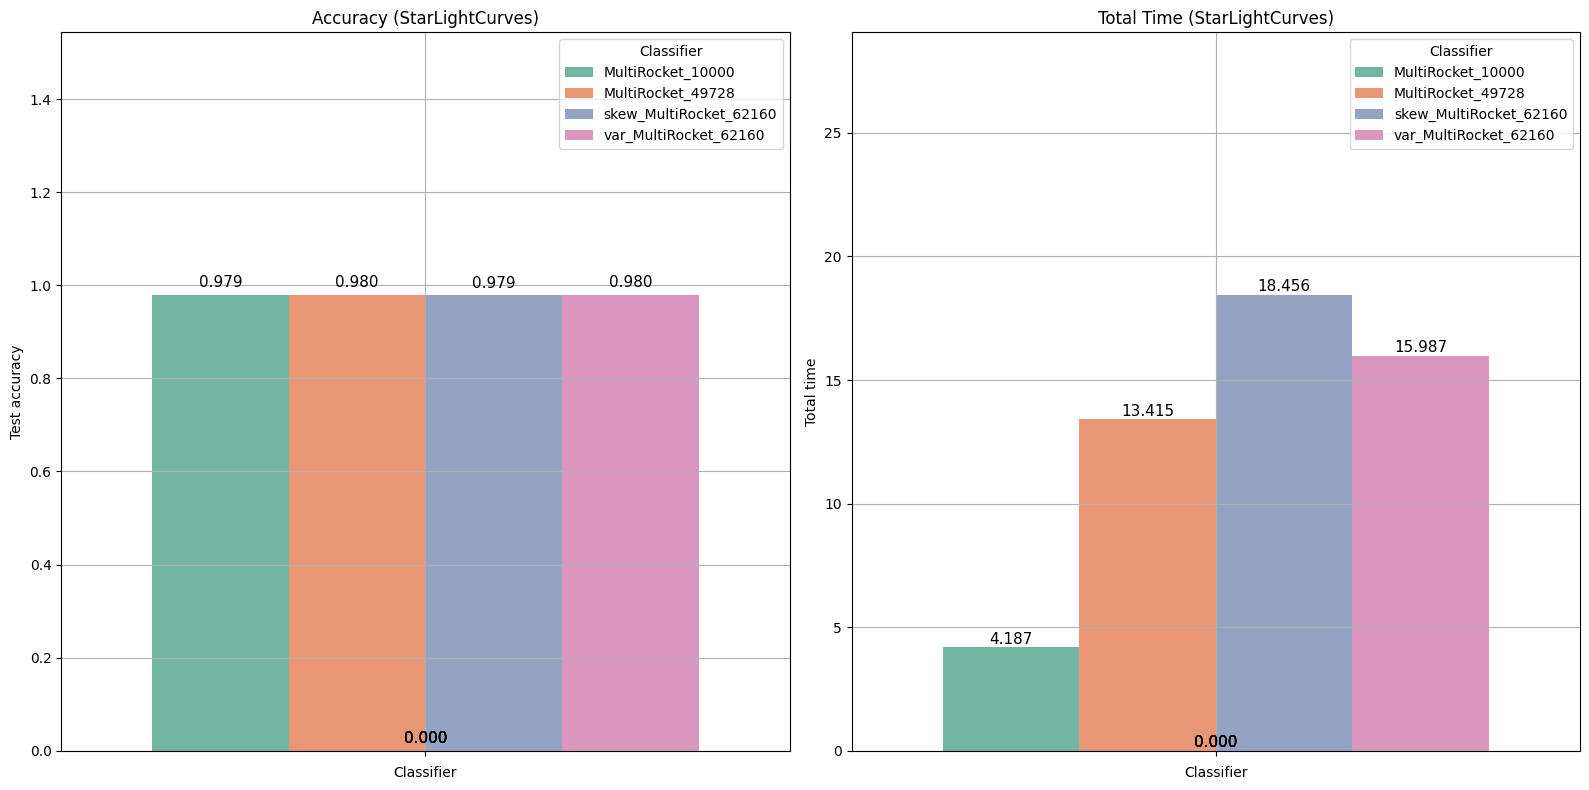

In [3]:
df_v1 = df.copy()

df_v1 = df_v1[~df_v1['classifier'].str.contains('mlp|rf|ker7')]

# Display
display(df_v1.head(20))

for dataset in df_v1['dataset'].unique():

    print(f"\n===== Dataset: {dataset} =====\n")

    plt.figure(figsize=(16, 8))

    plt.subplot(1, 2, 1)

    ax = sns.barplot(
        data=df_v1[df_v1['dataset'] == dataset],
        y='test_acc',
        width=0.75,
        hue='classifier',
        palette='Set2'
    )

    plt.title(f"Accuracy ({dataset})")
    plt.xlabel("Classifier")
    plt.ylabel("Test accuracy")
    plt.grid(True)

    # Add space for legend + text
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin, ymax * 1.5)

    # Add values on bars (rounded to 3 decimals)
    for p in ax.patches:
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        ax.text(x, y + 0.01, f"{y:.3f}", ha='center', va='bottom', fontsize=11)

    plt.legend(loc='upper right', title='Classifier')

    plt.subplot(1, 2, 2)

    ax2 = sns.barplot(
        data=df_v1[df_v1['dataset'] == dataset],
        y='total_time',
        width=0.75,
        hue='classifier',
        palette='Set2'
    )

    plt.title(f"Total Time ({dataset})")
    plt.xlabel("Classifier")
    plt.ylabel("Total time")
    plt.grid(True)

    # Add space for legend + text
    ymin, ymax = ax2.get_ylim()
    ax2.set_ylim(ymin, ymax * 1.5)

    # Add values on bars (rounded to 3 decimals)
    for p in ax2.patches:
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        ax2.text(x, y + 0.01, f"{y:.3f}", ha='center', va='bottom', fontsize=11)

    plt.legend(loc='upper right', title='Classifier')

    plt.tight_layout()
    plt.show()

---
---


# 3-2. Our second approach

We tried two times by changing the `LogisticRegression()` by : a `MLPClassifier()` then a `RandomForestClassifier()`.

Here are the charts for `test_acc` and `total_time`.

,timestamp,itr,classifier,num_features,dataset,train_acc,train_time,test_acc,test_time,generate_kernel_time,apply_kernel_on_train_time,apply_kernel_on_test_time,train_transform_time,test_transform_time,physical_cores,logical_cores,max_freq,min_freq,memory,total_time
0,2026-04-12 17:58:10,0,MultiRocket_10000,10000,Crop,-1,3.981797,0.748631,0.376854,0.003194,0.230747,0.490592,0.000398,0.000725,10,10,4,0,17.0,5.083183
1,2026-04-12 17:59:04,0,MultiRocket_49728,49728,Crop,-1,17.007639,0.753988,4.091698,0.009472,0.911977,2.049311,0.000408,0.001154,10,10,4,0,17.0,24.070097
3,2026-04-12 18:01:40,0,mlp_MultiRocket_49728,49728,Crop,-1,36.735356,0.728810,1.798680,0.009519,0.881211,1.953335,0.000312,0.000667,10,10,4,0,17.0,41.378101
4,2026-04-12 18:02:37,0,rf_MultiRocket_49728,49728,Crop,-1,16.694688,0.759940,1.918042,0.009182,0.888521,2.036433,0.000327,0.000682,10,10,4,0,17.0,21.546866
7,2026-04-12 17:51:00,0,MultiRocket_10000,10000,ElectricDevices,-1,9.197103,0.728699,0.168387,0.006050,0.476870,0.392664,0.000671,0.000719,10,10,4,0,17.0,10.241073
8,2026-04-12 17:51:41,0,MultiRocket_49728,49728,ElectricDevices,-1,21.356969,0.710543,0.829270,0.014629,1.874052,1.608996,0.000889,0.001484,10,10,4,0,17.0,25.683916
10,2026-04-12 17:55:36,0,mlp_MultiRocket_49728,49728,ElectricDevices,-1,86.728027,0.643367,0.853358,0.015070,1.787197,1.666584,0.000867,0.000632,10,10,4,0,17.0,91.050235
11,2026-04-12 17:56:36,0,rf_MultiRocket_49728,49728,ElectricDevices,-1,25.801489,0.724160,0.836891,0.014903,1.805381,1.633051,0.000892,0.000659,10,10,4,0,17.0,30.091715
14,2026-03-31 15:38:33,0,MultiRocket_10000,10000,InsectWingbeatSound,-1,0.694419,0.642424,0.042348,0.010279,0.027257,0.187848,0.000049,0.000408,10,10,4,0,17.0,0.962151
15,2026-03-31 15:38:45,0,MultiRocket_49728,49728,InsectWingbeatSound,-1,1.628165,0.637374,0.225057,0.027484,0.097459,0.855516,0.000080,0.000465,10,10,4,0,17.0,2.833681



===== Dataset: Crop =====



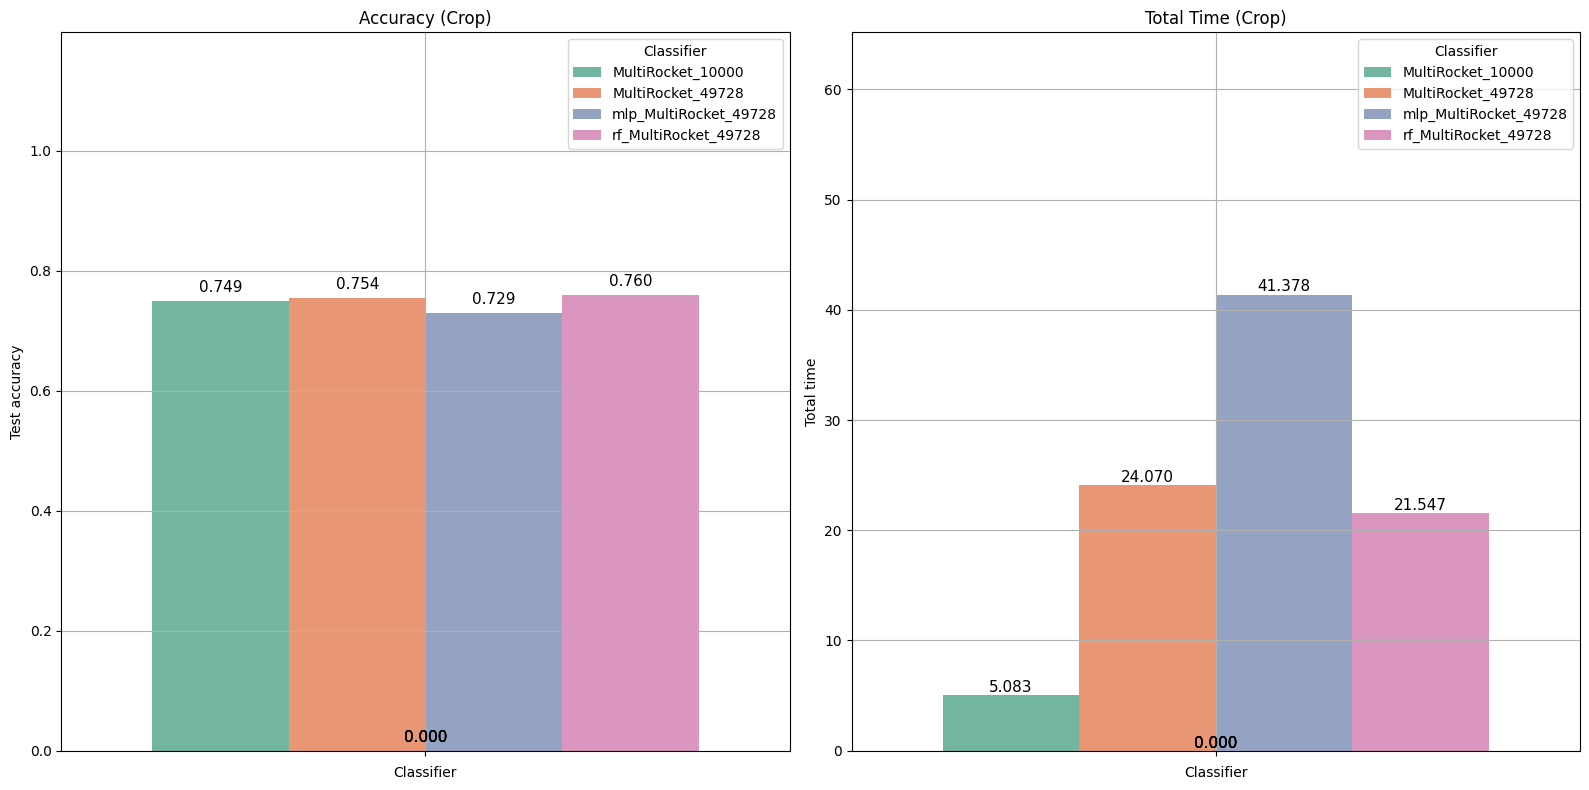


===== Dataset: ElectricDevices =====



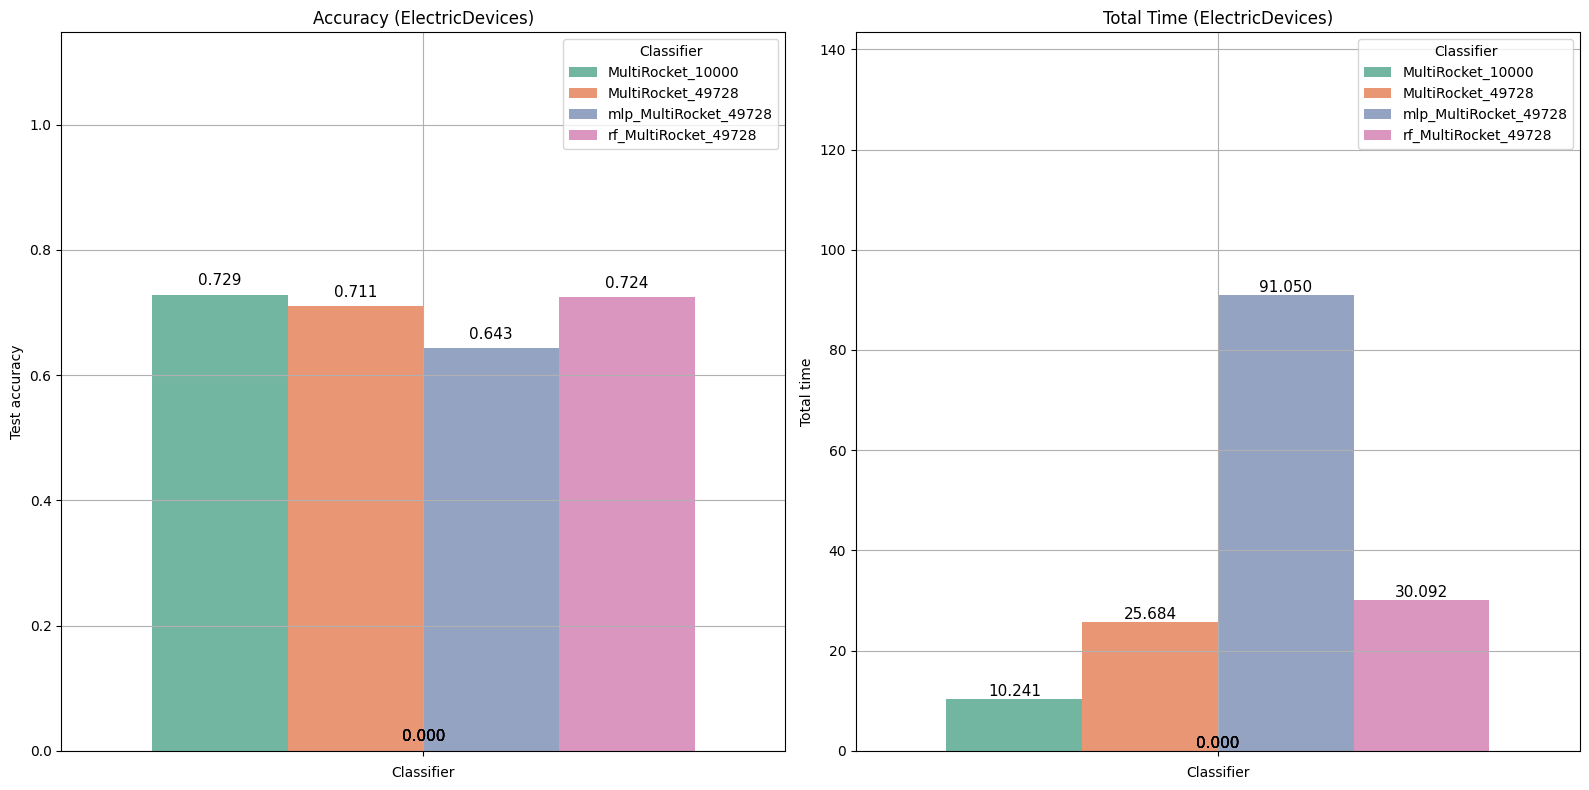


===== Dataset: InsectWingbeatSound =====



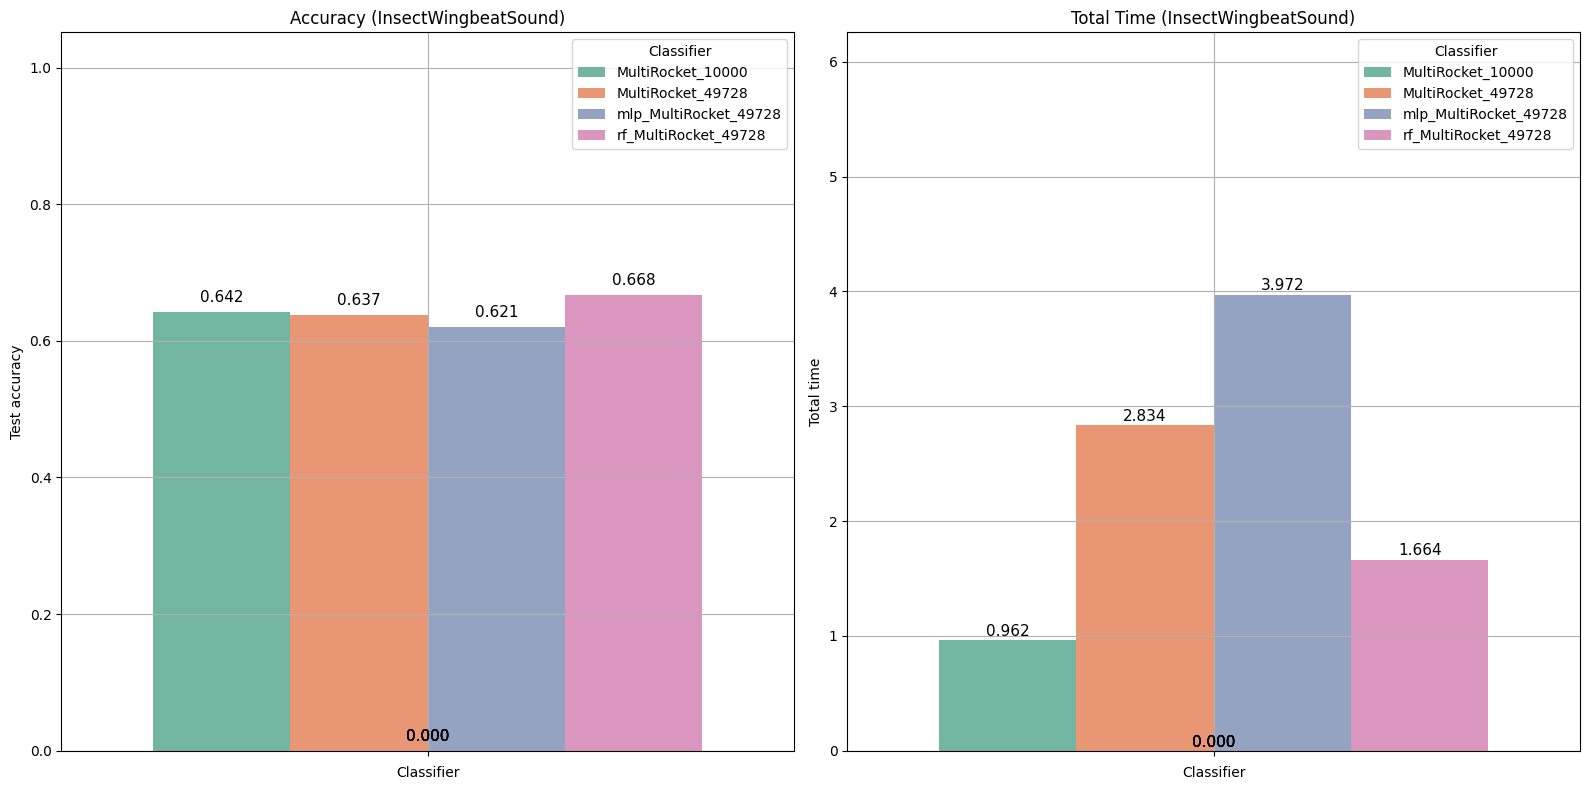


===== Dataset: StarLightCurves =====



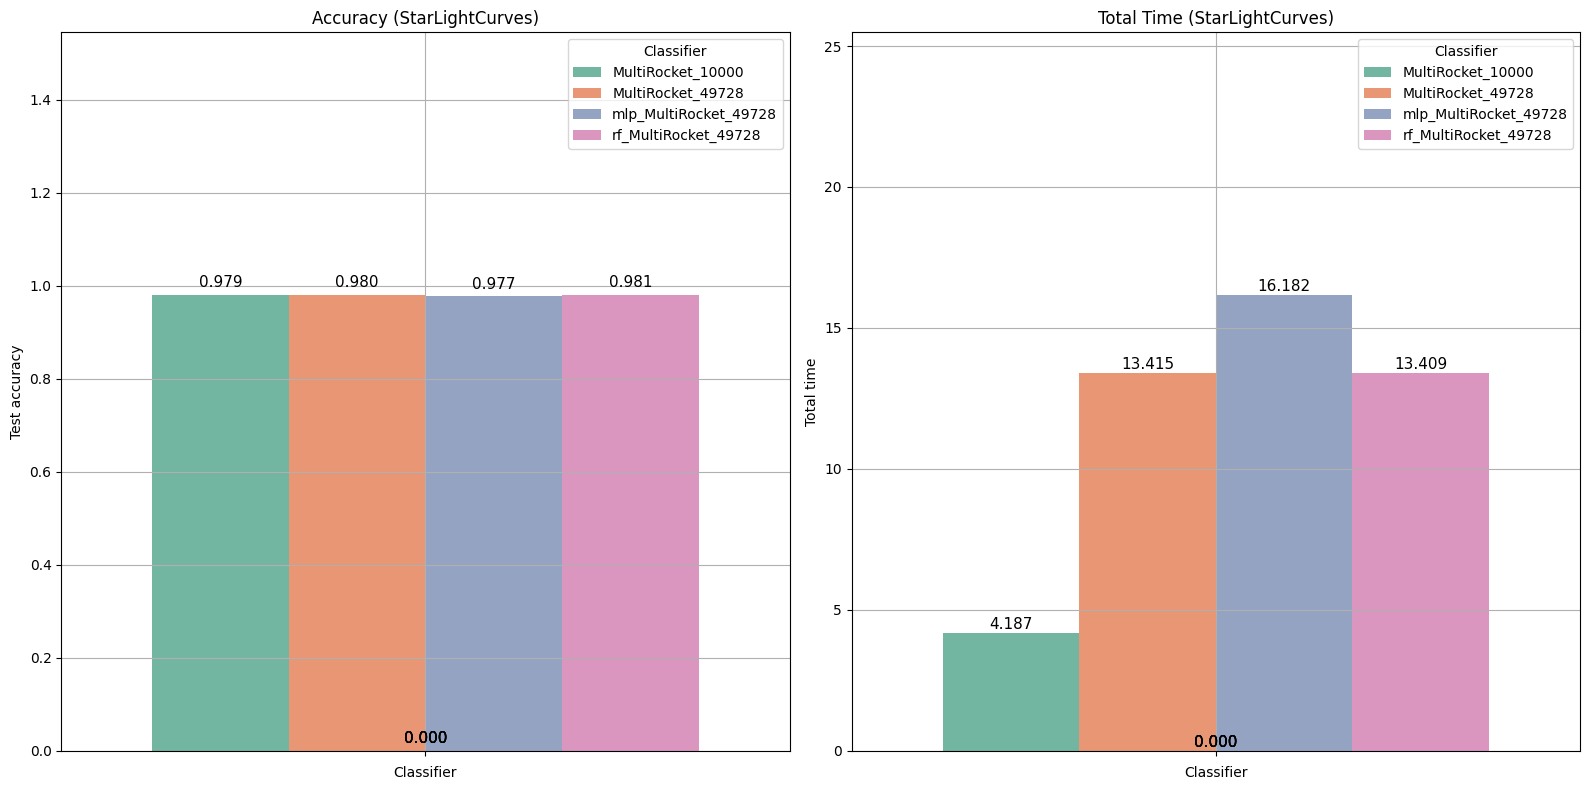

In [4]:
df_v2 = df.copy()

df_v2 = df_v2[~df_v2['classifier'].str.contains('skew|var|ker7')]

# Display
display(df_v2.head(20))

for dataset in df_v2['dataset'].unique():

    print(f"\n===== Dataset: {dataset} =====\n")

    plt.figure(figsize=(16, 8))

    plt.subplot(1, 2, 1)

    ax = sns.barplot(
        data=df_v2[df_v2['dataset'] == dataset],
        y='test_acc',
        width=0.75,
        hue='classifier',
        palette='Set2'
    )

    plt.title(f"Accuracy ({dataset})")
    plt.xlabel("Classifier")
    plt.ylabel("Test accuracy")
    plt.grid(True)

    # Add space for legend + text
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin, ymax * 1.5)

    # Add values on bars (rounded to 3 decimals)
    for p in ax.patches:
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        ax.text(x, y + 0.01, f"{y:.3f}", ha='center', va='bottom', fontsize=11)

    plt.legend(loc='upper right', title='Classifier')

    plt.subplot(1, 2, 2)

    ax2 = sns.barplot(
        data=df_v2[df_v2['dataset'] == dataset],
        y='total_time',
        width=0.75,
        hue='classifier',
        palette='Set2'
    )

    plt.title(f"Total Time ({dataset})")
    plt.xlabel("Classifier")
    plt.ylabel("Total time")
    plt.grid(True)

    # Add space for legend + text
    ymin, ymax = ax2.get_ylim()
    ax2.set_ylim(ymin, ymax * 1.5)

    # Add values on bars (rounded to 3 decimals)
    for p in ax2.patches:
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        ax2.text(x, y + 0.01, f"{y:.3f}", ha='center', va='bottom', fontsize=11)

    plt.legend(loc='upper right', title='Classifier')

    plt.tight_layout()
    plt.show()

---
---


# 3-3. Our third approach

We tried changing the `kernel size` from $9$ to $7$, going from $84$ kernels to $35$ kernels.  
Having now 20 720 features (35 * 74 * 2 * 5).

Here are the charts for `test_acc` and `total_time`.

,timestamp,itr,classifier,num_features,dataset,train_acc,train_time,test_acc,test_time,generate_kernel_time,apply_kernel_on_train_time,apply_kernel_on_test_time,train_transform_time,test_transform_time,physical_cores,logical_cores,max_freq,min_freq,memory,total_time
0,2026-04-12 17:58:10,0,MultiRocket_10000,10000,Crop,-1,3.981797,0.748631,0.376854,0.003194,0.230747,0.490592,0.000398,0.000725,10,10,4,0,17.0,5.083183
1,2026-04-12 17:59:04,0,MultiRocket_49728,49728,Crop,-1,17.007639,0.753988,4.091698,0.009472,0.911977,2.049311,0.000408,0.001154,10,10,4,0,17.0,24.070097
2,2026-04-12 18:03:11,0,ker7_MultiRocket_20720,20720,Crop,-1,12.621512,0.751726,0.751807,0.004408,0.369528,0.828867,0.000366,0.000703,10,10,4,0,17.0,14.576122
7,2026-04-12 17:51:00,0,MultiRocket_10000,10000,ElectricDevices,-1,9.197103,0.728699,0.168387,0.006050,0.476870,0.392664,0.000671,0.000719,10,10,4,0,17.0,10.241073
8,2026-04-12 17:51:41,0,MultiRocket_49728,49728,ElectricDevices,-1,21.356969,0.710543,0.829270,0.014629,1.874052,1.608996,0.000889,0.001484,10,10,4,0,17.0,25.683916
9,2026-04-12 17:57:33,0,ker7_MultiRocket_20720,20720,ElectricDevices,-1,15.262001,0.717417,0.357970,0.006803,0.772875,0.664123,0.000883,0.000723,10,10,4,0,17.0,17.063772
14,2026-03-31 15:38:33,0,MultiRocket_10000,10000,InsectWingbeatSound,-1,0.694419,0.642424,0.042348,0.010279,0.027257,0.187848,0.000049,0.000408,10,10,4,0,17.0,0.962151
15,2026-03-31 15:38:45,0,MultiRocket_49728,49728,InsectWingbeatSound,-1,1.628165,0.637374,0.225057,0.027484,0.097459,0.855516,0.000080,0.000465,10,10,4,0,17.0,2.833681
16,2026-04-09 19:23:43,0,ker7_MultiRocket_20720,20720,InsectWingbeatSound,-1,1.355187,0.637879,0.145321,0.011803,0.049037,0.384341,0.000082,0.000585,10,10,4,0,17.0,1.945689
21,2026-03-31 15:39:20,0,MultiRocket_10000,10000,StarLightCurves,-1,1.652332,0.979480,0.201358,0.031560,0.254880,2.047145,0.000915,0.008832,10,10,4,0,17.0,4.187275



===== Dataset: Crop =====



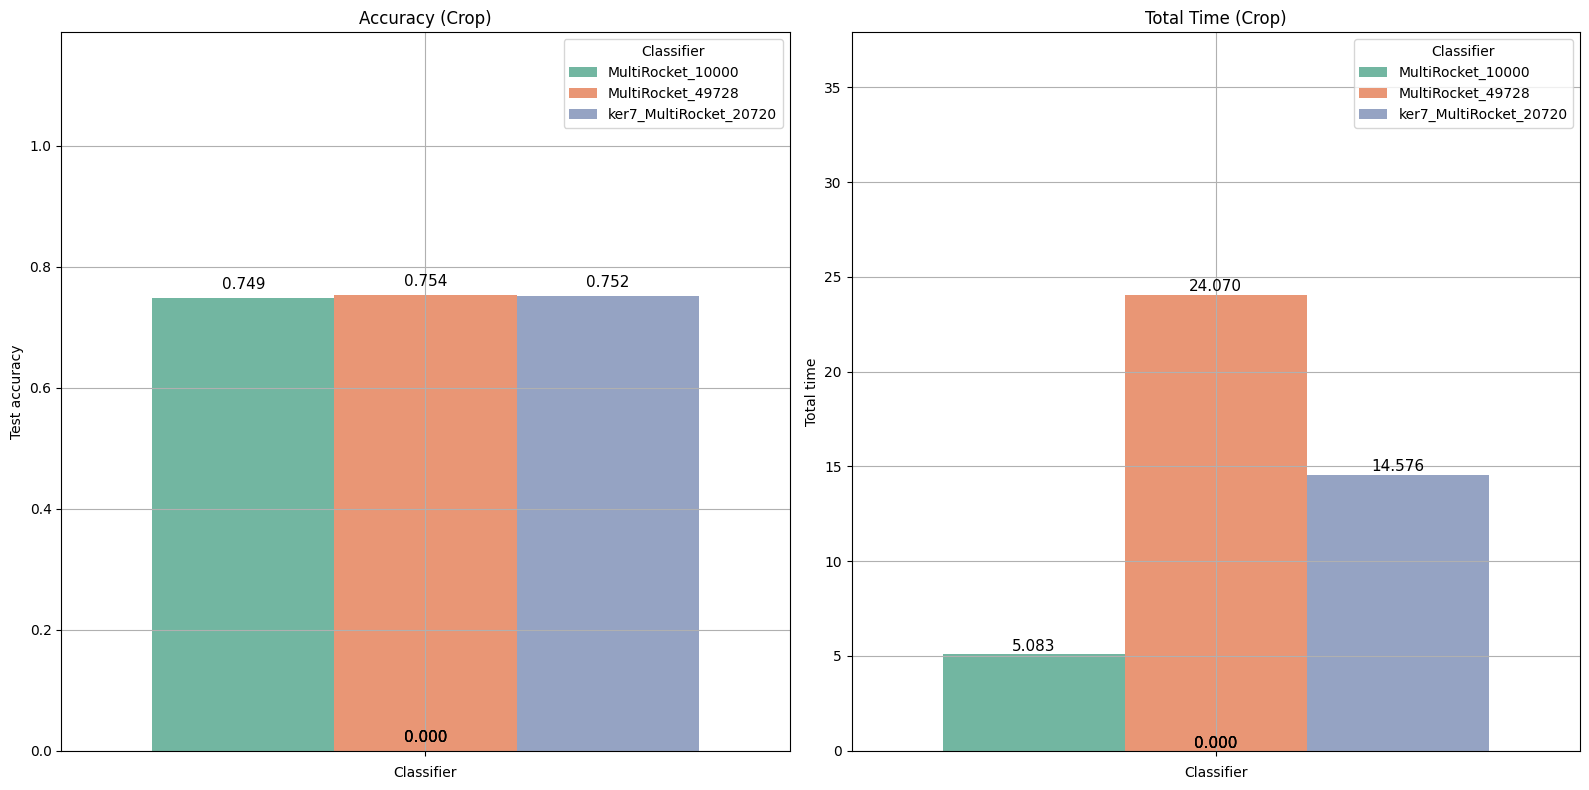


===== Dataset: ElectricDevices =====



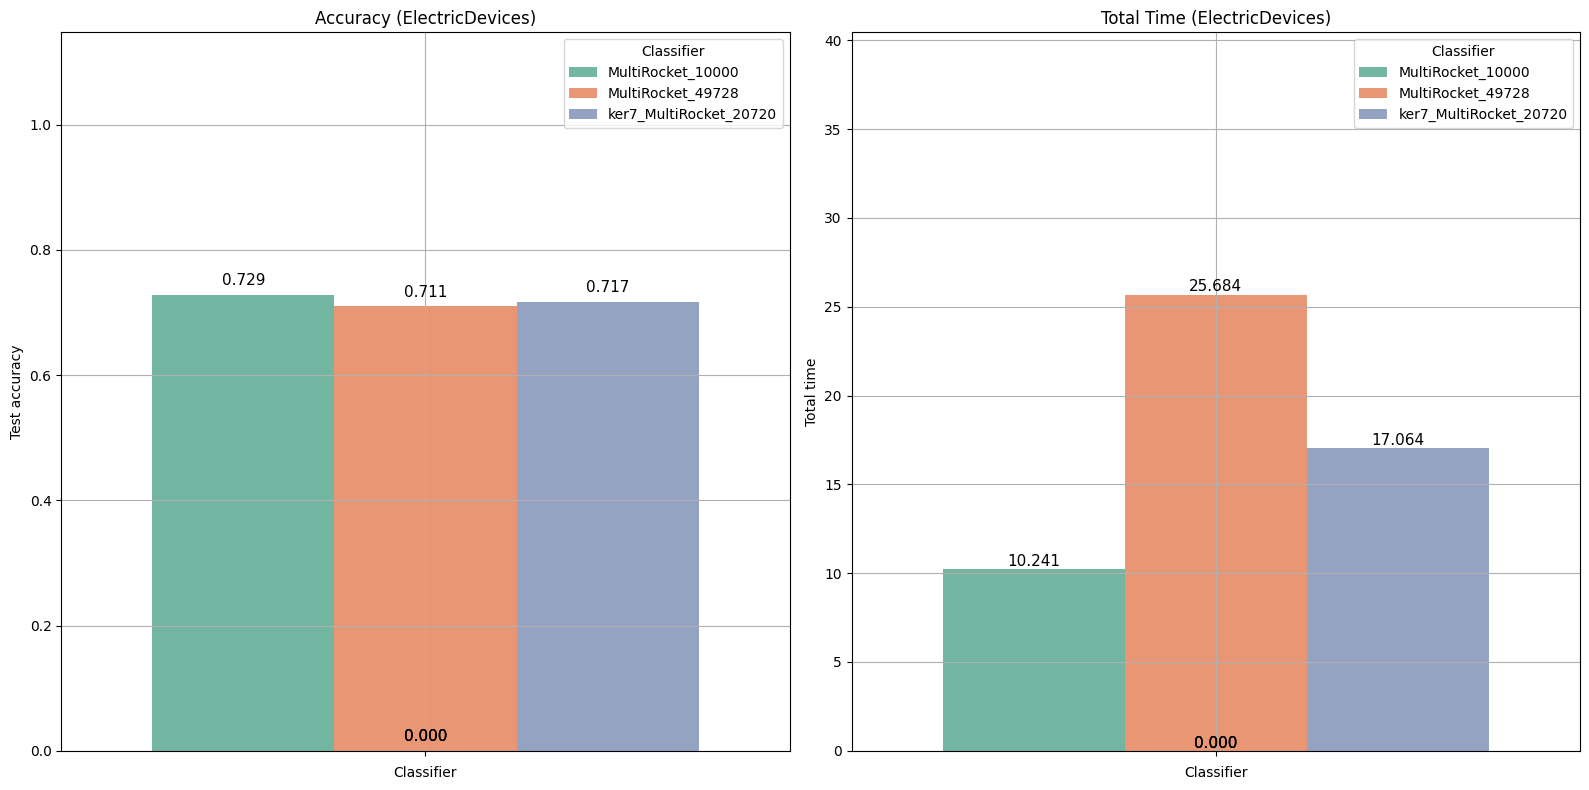


===== Dataset: InsectWingbeatSound =====



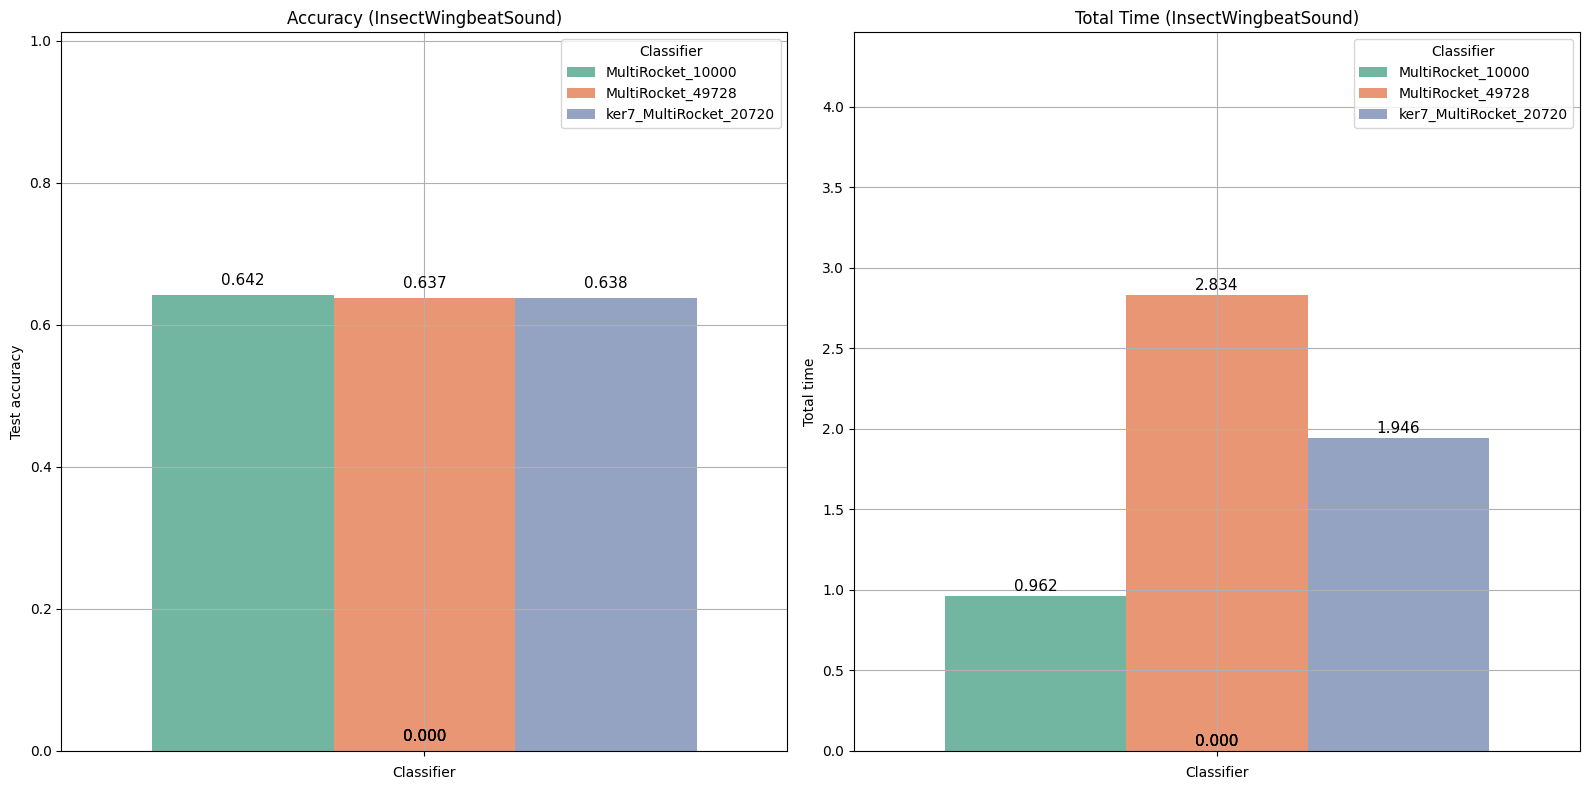


===== Dataset: StarLightCurves =====



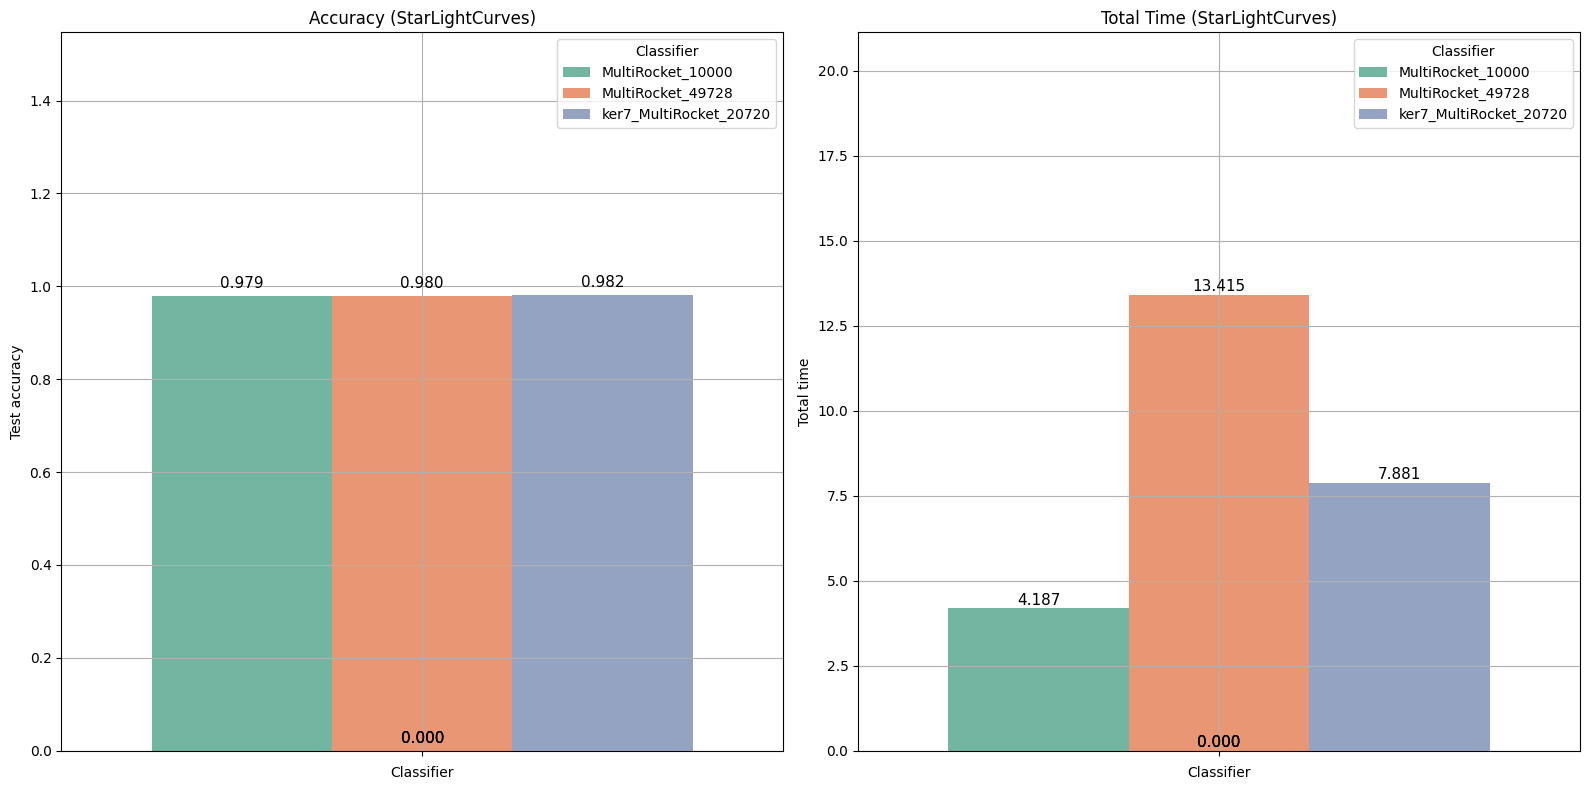

In [5]:
df_v3 = df.copy()

df_v3 = df_v3[~df_v3['classifier'].str.contains('skew|var|mlp|rf')]

# Display
display(df_v3.head(20))

for dataset in df_v3['dataset'].unique():

    print(f"\n===== Dataset: {dataset} =====\n")

    plt.figure(figsize=(16, 8))

    plt.subplot(1, 2, 1)

    ax = sns.barplot(
        data=df_v3[df_v3['dataset'] == dataset],
        y='test_acc',
        width=0.75,
        hue='classifier',
        palette='Set2'
    )

    plt.title(f"Accuracy ({dataset})")
    plt.xlabel("Classifier")
    plt.ylabel("Test accuracy")
    plt.grid(True)

    # Add space for legend + text
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin, ymax * 1.5)

    # Add values on bars (rounded to 3 decimals)
    for p in ax.patches:
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        ax.text(x, y + 0.01, f"{y:.3f}", ha='center', va='bottom', fontsize=11)

    plt.legend(loc='upper right', title='Classifier')

    plt.subplot(1, 2, 2)

    ax2 = sns.barplot(
        data=df_v3[df_v3['dataset'] == dataset],
        y='total_time',
        width=0.75,
        hue='classifier',
        palette='Set2'
    )

    plt.title(f"Total Time ({dataset})")
    plt.xlabel("Classifier")
    plt.ylabel("Total time")
    plt.grid(True)

    # Add space for legend + text
    ymin, ymax = ax2.get_ylim()
    ax2.set_ylim(ymin, ymax * 1.5)

    # Add values on bars (rounded to 3 decimals)
    for p in ax2.patches:
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        ax2.text(x, y + 0.01, f"{y:.3f}", ha='center', va='bottom', fontsize=11)

    plt.legend(loc='upper right', title='Classifier')

    plt.tight_layout()
    plt.show()

---
---


# 4. Our analysis

We can now analyse our 7 models (2 baselines and 5 variants) across the 4 biggest UCR datasets :

- `InsectWingbeatSound`
- `StarLightCurves`
- `ElectricDevices`
- `Crop`

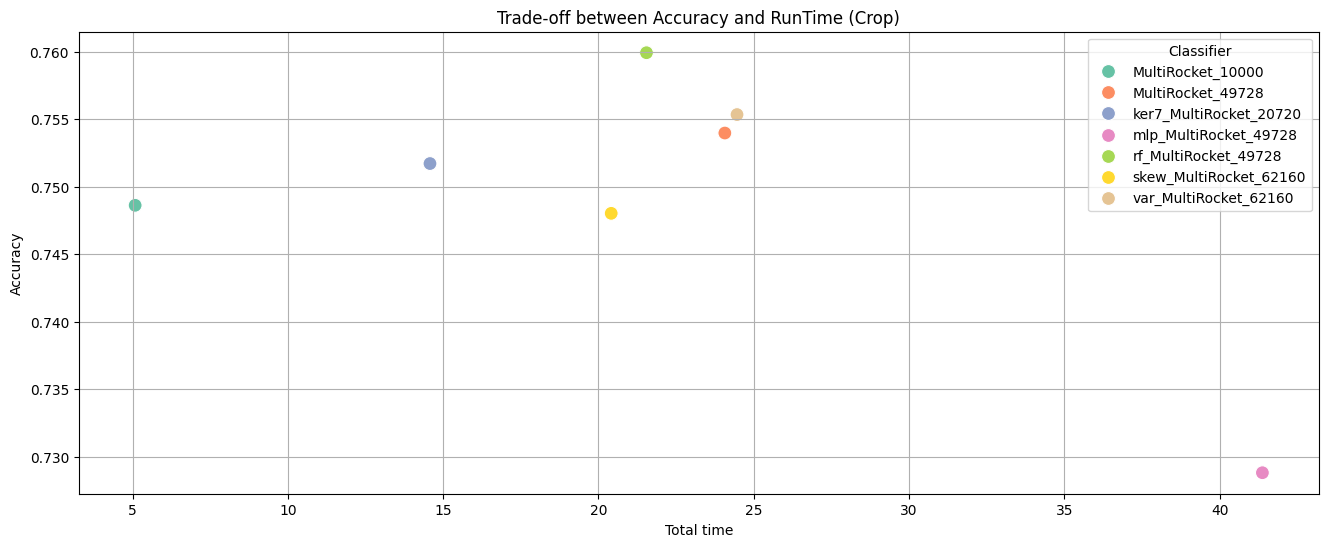

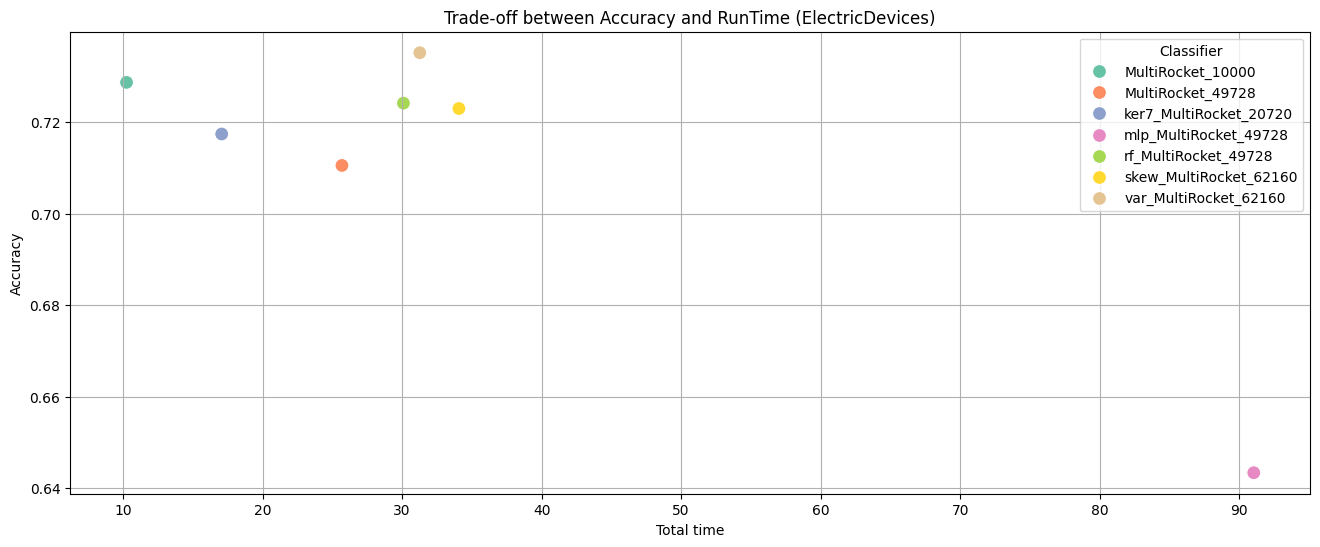

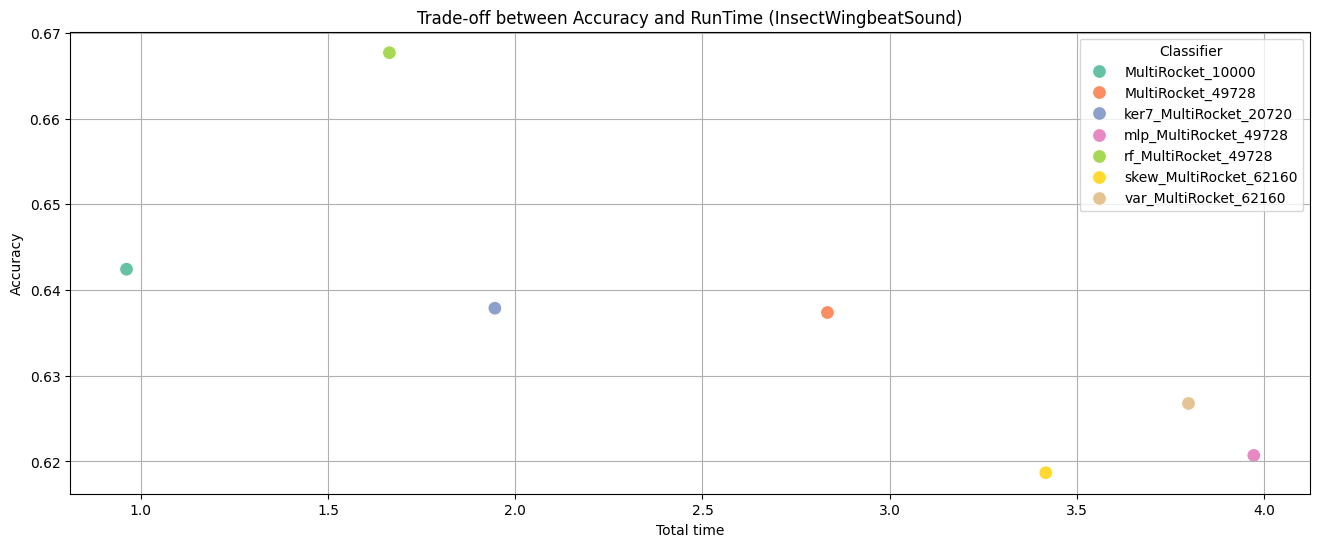

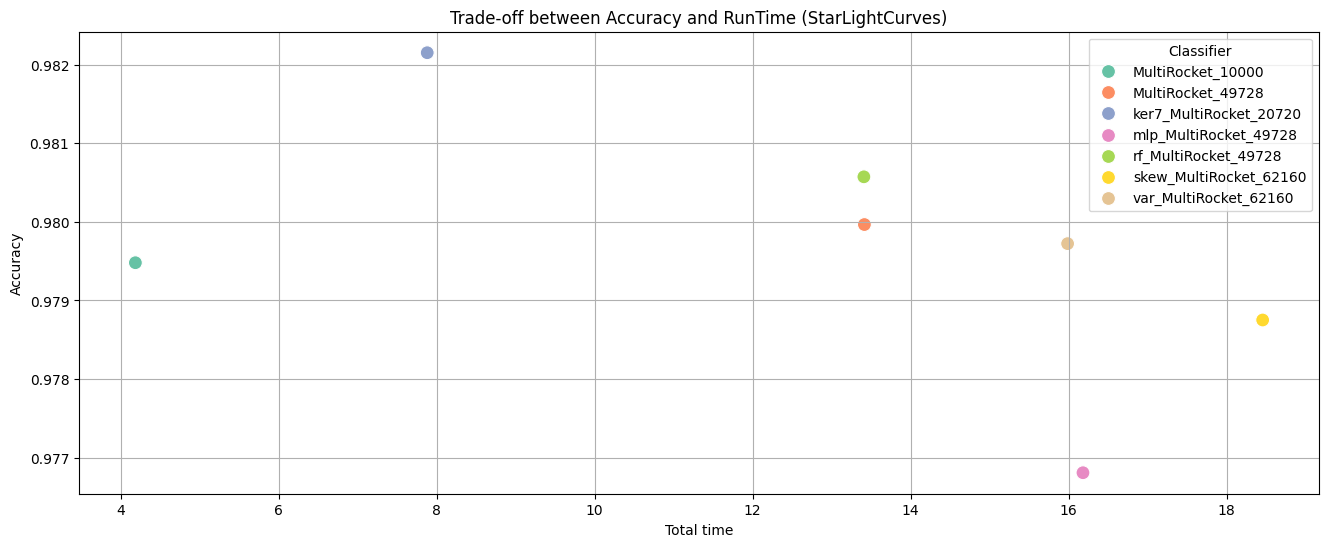

In [6]:
for i, dataset in enumerate(df['dataset'].unique()):
    
    plt.figure(figsize=(16, 6))

    #plt.subplot(2, 2, i+1)

    sns.scatterplot(data=df[df['dataset'] == dataset], x='total_time', y='test_acc', s=100, hue='classifier', palette='Set2')

    plt.title(f"Trade-off between Accuracy and RunTime ({dataset})")
    plt.xlabel("Total time")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.legend(loc='upper right', title='Classifier')

In [7]:
df_rank = df.copy()
df_rank['rank'] = df.groupby('dataset')['test_acc'].rank(ascending=False, method='min').astype(int)
display(df_rank[['dataset', 'classifier', 'test_acc', 'rank']].sort_values(['dataset', 'rank']))

,dataset,classifier,test_acc,rank
4,Crop,rf_MultiRocket_49728,0.759940,1
6,Crop,var_MultiRocket_62160,0.755357,2
1,Crop,MultiRocket_49728,0.753988,3
2,Crop,ker7_MultiRocket_20720,0.751726,4
0,Crop,MultiRocket_10000,0.748631,5
5,Crop,skew_MultiRocket_62160,0.748036,6
3,Crop,mlp_MultiRocket_49728,0.728810,7
13,ElectricDevices,var_MultiRocket_62160,0.735184,1
7,ElectricDevices,MultiRocket_10000,0.728699,2
11,ElectricDevices,rf_MultiRocket_49728,0.724160,3


In [8]:
df_pivot = df_rank.pivot(index='dataset', columns='classifier', values='test_acc') # rank
display(df_pivot)

classifier,MultiRocket_10000,MultiRocket_49728,ker7_MultiRocket_20720,mlp_MultiRocket_49728,rf_MultiRocket_49728,skew_MultiRocket_62160,var_MultiRocket_62160
dataset,,,,,,,
Crop,0.748631,0.753988,0.751726,0.728810,0.759940,0.748036,0.755357
ElectricDevices,0.728699,0.710543,0.717417,0.643367,0.724160,0.722993,0.735184
InsectWingbeatSound,0.642424,0.637374,0.637879,0.620707,0.667677,0.618687,0.626768
StarLightCurves,0.979480,0.979966,0.982152,0.976809,0.980573,0.978752,0.979723


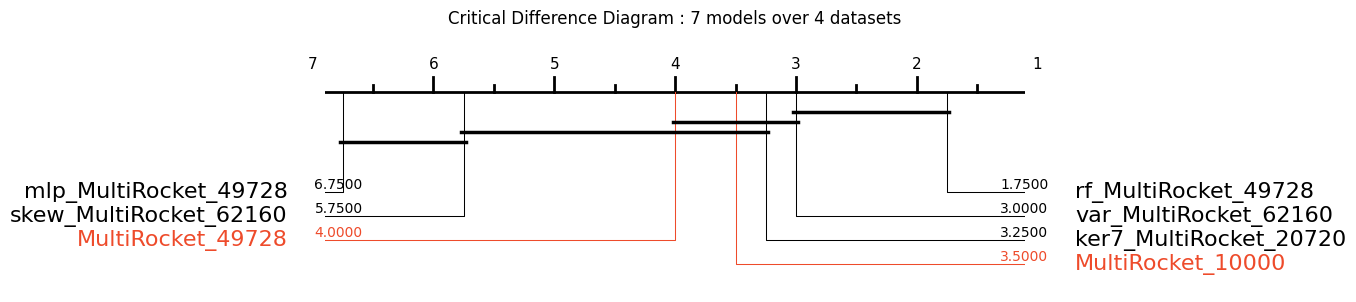

In [9]:
from aeon.visualisation import plot_critical_difference, create_multi_comparison_matrix
import numpy as np
import math

results = df_pivot.values  # shape (n_datasets, n_classifiers)
methods = df_pivot.columns.tolist()

cdd = plot_critical_difference(results, methods,
                                highlight={"MultiRocket_10000":"#EE4B2B", "MultiRocket_49728":"#EE4B2B"},
                                lower_better=False,
                                test='wilcoxon', correction='holm', width=7,
                                textspace=0.6, reverse=True, alpha=1, return_p_values=True)

plt.title("Critical Difference Diagram : 7 models over 4 datasets")
plt.show()

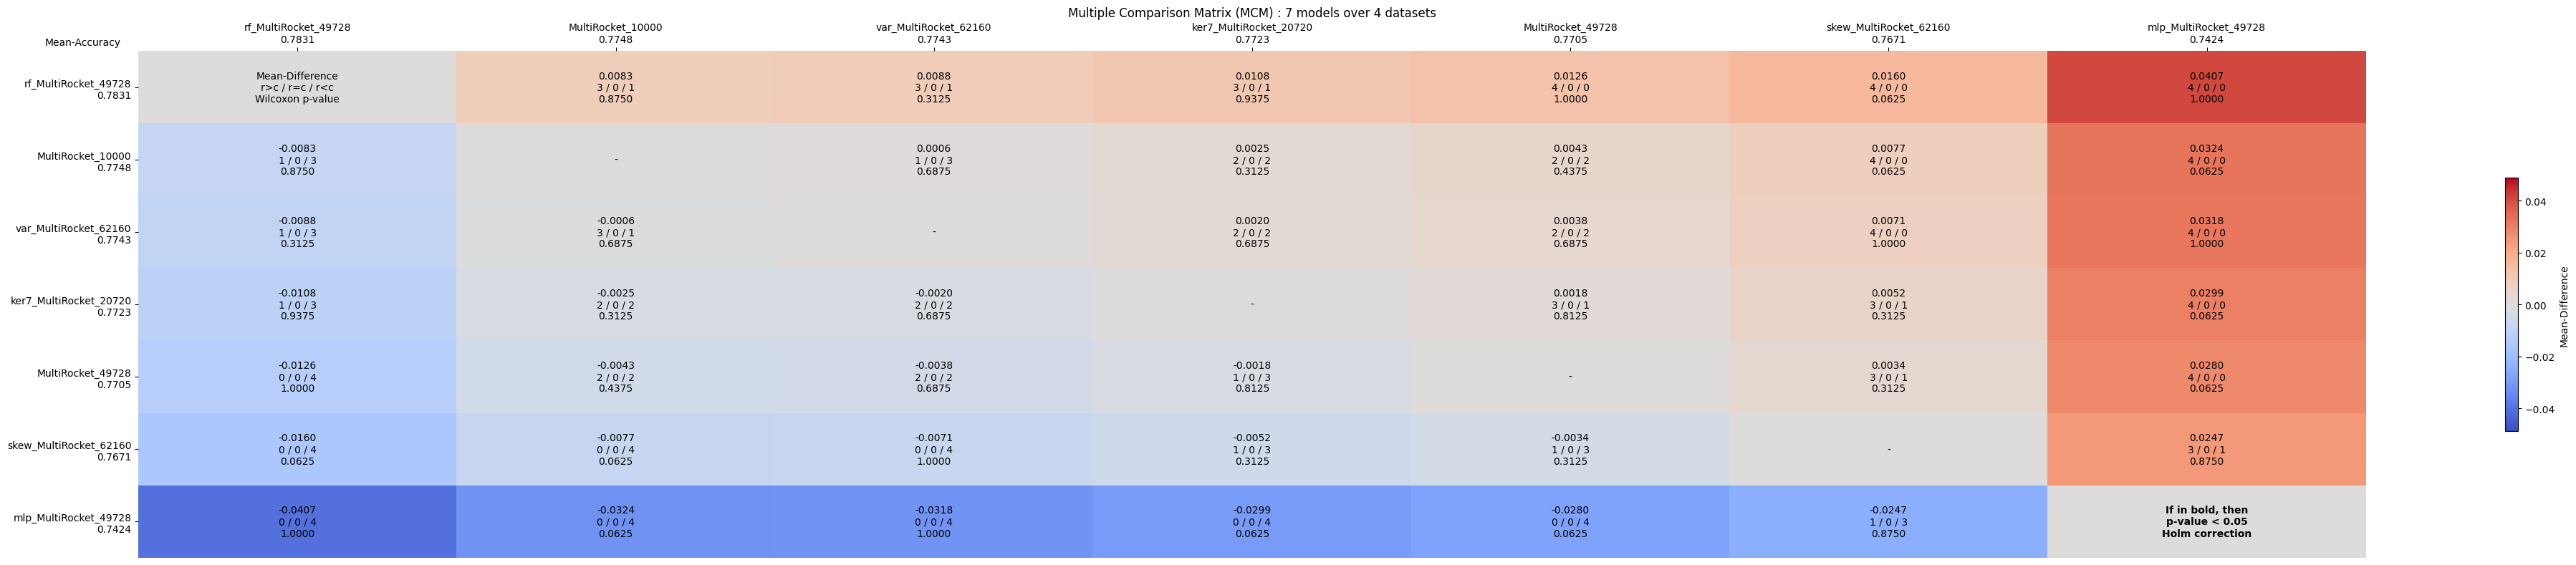

In [10]:
mcm = create_multi_comparison_matrix(df_pivot, pvalue_test='wilcoxon', pvalue_correction='Holm')

plt.title("Multiple Comparison Matrix (MCM) : 7 models over 4 datasets")
plt.show()